<a href="https://colab.research.google.com/github/vedant-63/AIML-classes/blob/main/Helmet_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

Mon Jul 20 14:10:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install ultralytics roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 77.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 132.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 5.0.0.93
    Uninstalling opencv-python-headless-5.0.0.93:
      Successfully uninstalled opencv-python-headless-5.0.0.93
  Attempting uninstall: typer
    Found existing installation: typer 0.26.8
    Uninstalling typer-0.26.8:
      Successfully uninstalled typer-0.26.8


In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key="QxSUNPxMVmxEGcnYKKxt")
project = rf.workspace("vedants-workspace-tbsco").project("helmet-detection-hvnvh")
dataset = project.version(1).download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to helmet-detection-1 in yolov11:: 100%|██████████| 2095/2095 [00:00<00:00, 6422.88it/s]


In [ ]:
!ls helmet-detection-1

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [ ]:
!cat helmet-detection-1/data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 2
names: ['0', '1']

roboflow:
  workspace: vedants-workspace-tbsco
  project: helmet-detection-hvnvh
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/vedants-workspace-tbsco/helmet-detection-hvnvh/dataset/1

In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
model = YOLO("yolo11n.pt")

In [ ]:
results = model.train(
    data="/content/helmet-detection-1/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    project="Helmet_Detection",
    name="Helmet_AI_Model"
)

Ultralytics 8.4.102 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/helmet-detection-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Helmet_AI_Model, nbs=64, nms=False, opset=None, optimize=False, optimizer=au

In [ ]:
!ls /content/runs/detect/Helmet_Detection/Helmet_AI_Model/weights

best.pt  last.pt


In [11]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/Helmet_Detection/Helmet_AI_Model/weights/best.pt")

results = model.predict(
    source="/content/helmet-detection-1/test/images",
    save=True,
    conf=0.5
)


image 1/156 /content/helmet-detection-1/test/images/109_jpg.rf.393bc68c55d8eba7d4d1f79a1b319948.jpg: 640x640 1 0, 15.9ms
image 2/156 /content/helmet-detection-1/test/images/11_jpg.rf.5997bac749d13d2845716710ef9325c7.jpg: 640x640 1 0, 13.9ms
image 3/156 /content/helmet-detection-1/test/images/131_jpg.rf.b4b294976e952120ff844f9287afeff6.jpg: 640x640 1 0, 17.0ms
image 4/156 /content/helmet-detection-1/test/images/135_jpg.rf.3630f29a7f6fed34148967274a890969.jpg: 640x640 1 0, 20.0ms
image 5/156 /content/helmet-detection-1/test/images/136_jpg.rf.afdcde8200c698a53e2c2f686e1207bd.jpg: 640x640 (no detections), 20.4ms
image 6/156 /content/helmet-detection-1/test/images/143_jpg.rf.a49f908695275b019fc51dd8c10fb8ea.jpg: 640x640 7 0s, 17.9ms
image 7/156 /content/helmet-detection-1/test/images/148_jpg.rf.f5c9ace700e94463d1875dab813e9308.jpg: 640x640 3 0s, 16.4ms
image 8/156 /content/helmet-detection-1/test/images/165_jpg.rf.5c7648d6d55bf8791b43f2ac4e0d0dcc.jpg: 640x640 1 0, 15.1ms
image 9/156 /conte

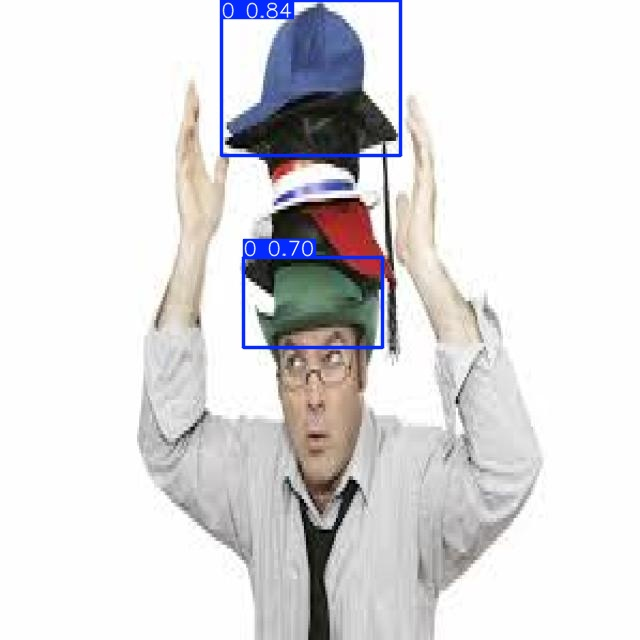

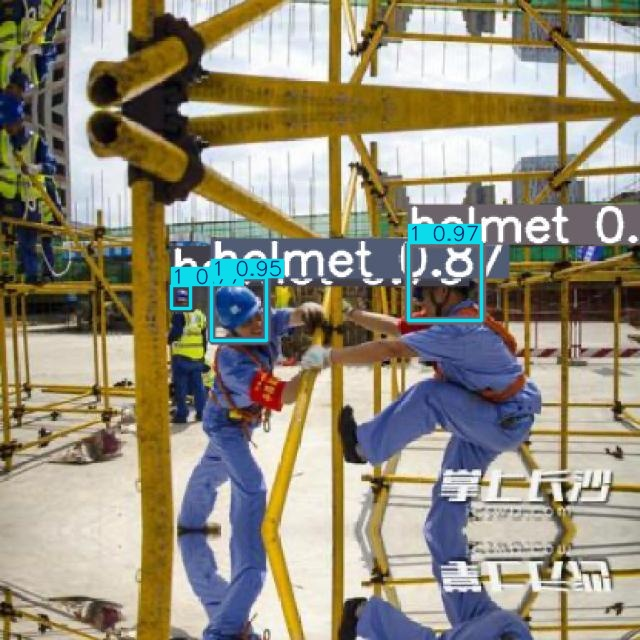

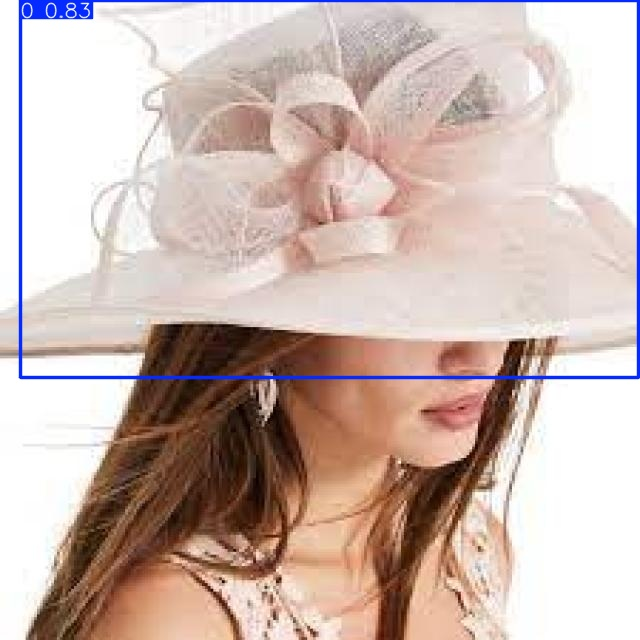

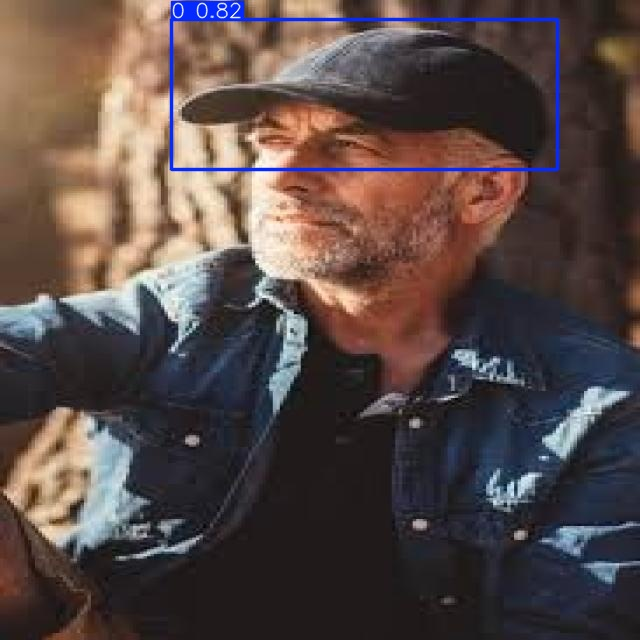

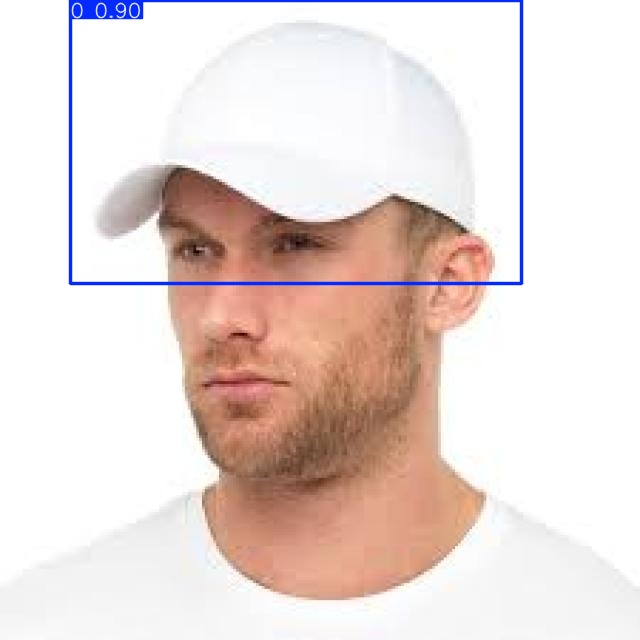

In [12]:
import os
from IPython.display import Image, display

output_folder = "/content/runs/detect/predict"

files = os.listdir(output_folder)

for f in files[:5]:
    display(Image(filename=os.path.join(output_folder, f)))